# **Introduction to PCA**
- **`PCA on MNIST`**

- PCA is a dimensionality reduction technique used to transform high-dimensional data into a smaller set of meaningful components.
while preserving most of the information in the data.
- In image datasets like MNIST, each image contains many pixel features. PCA helps reduce these features into fewer components, making models faster and easier to train.


### **Steps of PCA:**
1. Standardize the data. 
2. Compute the covariance matrix.
3. Perform eigen decomposition to obtain eigenvalues and eigenvectors.
4. Sort eigenvalues in descending order and select top components.
5. Project the original data onto the selected eigenvectors.

## **Import Libraries**

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

## **Load dataset**

In [12]:
df = pd.read_csv('C:/Users/Awais/Downloads/train.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
df.shape

(42000, 785)

In [15]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
29072,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## **Visualize a Digit Image**

Text(0.5, 1.0, 'Sample MNIST Digit')

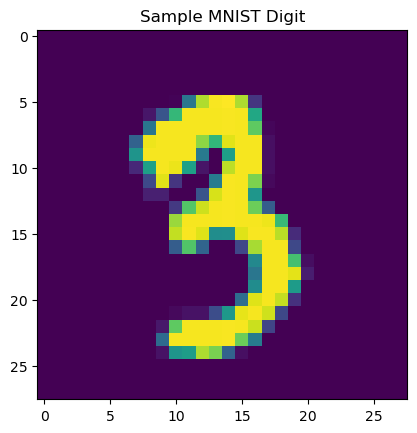

In [19]:
plt.imshow(df.iloc[29072,1:].values.reshape(28,28))
plt.title("Sample MNIST Digit")


Text(0.5, 1.0, 'Sample MNIST Digit')

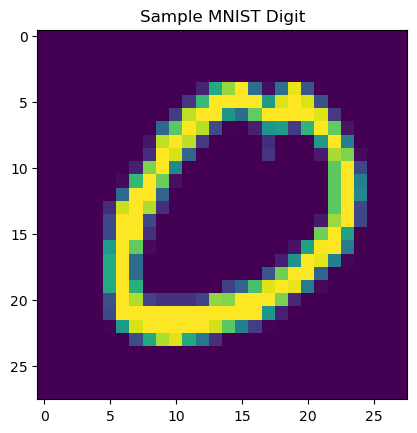

In [20]:
plt.imshow(df.iloc[13051,1:].values.reshape(28,28))
plt.title("Sample MNIST Digit")


- This plot displays a handwritten digit from the dataset.

## **Separate Features and Labels**

In [21]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

#### Train-Test Split

- We divide the dataset into training and testing sets to evaluate model performance.

In [22]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [23]:
X_train.shape

(33600, 784)

In [24]:
from sklearn.neighbors import KNeighborsClassifier

In [25]:
knn = KNeighborsClassifier()

In [26]:
knn.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [27]:
y_pred = knn.predict(X_test)


In [29]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9648809523809524

## **Step_01:Standardize the Data**

In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [30]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

- The dataset is now standardized with mean 0 and variance 1.

### **Applying PCA**

- PCA transforms the original pixel features into a smaller set of principal components that capture the most important variance in the data.

In [31]:
# PCA 
from sklearn.decomposition import PCA


In [32]:
pca = PCA()

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [33]:
X_train_pca.shape

(33600, 784)

## **Explained Variance**

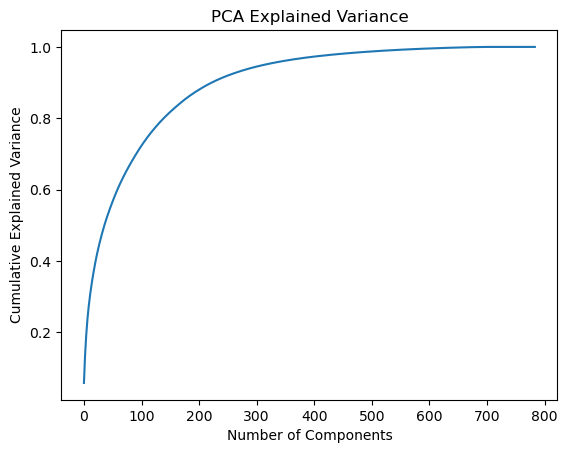

In [34]:
explained_variance = pca.explained_variance_ratio_

plt.plot(np.cumsum(explained_variance))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

## **Dimensionality Reduction**

- We now reduce the dataset to a smaller number of components while keeping most of the variance.

In [35]:
pca = PCA(n_components=50)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

X_train_pca.shape

(33600, 50)

- The dataset is now reduced to 50 principal components.

## **Model Training After PCA**
- After reducing dimensionality, we train a classifier on the transformed dataset.

In [36]:
knn = KNeighborsClassifier()
knn.fit(X_train_pca, y_train)

accuracy = knn.score(X_test_pca, y_test)
accuracy

0.9533333333333334

## **Finding Best Number of PCA Components**

In [37]:
for i in range(1,785):
    pca = PCA(n_components=i)
    X_train_trf = pca.fit_transform(X_train)
    X_test_trf = pca.transform(X_test)
    
    knn = KNeighborsClassifier()
    
    knn.fit(X_train_trf,y_train)
    
    y_pred = knn.predict(X_test_trf)
    
    print(accuracy_score(y_test,y_pred))
    

0.2730952380952381
0.42214285714285715
0.48488095238095236
0.6194047619047619
0.7297619047619047
0.8188095238095238
0.866904761904762
0.8938095238095238
0.9075
0.9247619047619048
0.9315476190476191
0.9421428571428572
0.9492857142857143
0.954047619047619
0.9544047619047619
0.9583333333333334
0.9616666666666667
0.9626190476190476
0.9644047619047619
0.9654761904761905
0.9665476190476191
0.9683333333333334
0.9694047619047619
0.9703571428571428
0.9704761904761905
0.9709523809523809
0.9708333333333333
0.9705952380952381
0.9714285714285714
0.9716666666666667
0.9725
0.9720238095238095
0.9705952380952381
0.9716666666666667
0.9710714285714286
0.9721428571428572
0.9726190476190476
0.9720238095238095
0.9729761904761904
0.9725
0.9721428571428572
0.9721428571428572
0.9726190476190476
0.9721428571428572
0.9717857142857143
0.9717857142857143
0.9727380952380953
0.9732142857142857
0.9730952380952381
0.9722619047619048
0.9730952380952381
0.9730952380952381
0.9727380952380953
0.9723809523809523
0.97226190

- This loop evaluates how classification accuracy changes as the number of PCA components increases.

### **PCA Visualization in 2D**
- To understand how PCA separates digit classes, we reduce the dataset to two principal components and visualize it.

In [39]:
pca = PCA(n_components=2)

X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

X_train_trf[:5]

array([[ -226.60523462,  -305.89437099],
       [   38.33583717,   461.09152047],
       [ -305.49225463,   351.67141678],
       [   82.8541043 , -1106.89501387],
       [ -686.38380343,  -649.67558415]])

In [40]:
X_train_trf

array([[-226.60523462, -305.89437099],
       [  38.33583717,  461.09152047],
       [-305.49225463,  351.67141678],
       ...,
       [ -28.00133402, -596.06287179],
       [ 233.97011308,  -18.64779077],
       [1096.50373629,  254.72333173]], shape=(33600, 2))

Each data point is now represented using only two principal components.

### **2D Visualization using Plotly**

In [41]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter(x=X_train_trf[:,0],
                 y=X_train_trf[:,1],
                 color=y_train_trf,
                 color_discrete_sequence=px.colors.qualitative.G10
                )
fig.show()

## **PCA Visualization in 3D**
- Reducing the dataset to three components allows us to observe more structure in the data compared to the 2D projection.

In [42]:
# transforming in 3D
pca = PCA(n_components=3)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [43]:
X_train_trf

array([[-226.60523462, -305.89437099, -417.17563833],
       [  38.33583717,  461.09152047, -100.40840682],
       [-305.49225463,  351.67141678,  961.3475787 ],
       ...,
       [ -28.00133402, -596.06287179, -606.25130926],
       [ 233.97011308,  -18.64779077,  148.27481803],
       [1096.50373629,  254.72333173,  560.33354832]], shape=(33600, 3))

In [45]:
import plotly.express as px

y_train_trf = y_train.astype(str)

fig = px.scatter_3d(
    x=X_train_trf[:,0],
    y=X_train_trf[:,1],
    z=X_train_trf[:,2],
    color=y_train_trf
)

fig.update_layout(
    margin=dict(l=20, r=20, t=20, b=20),
    paper_bgcolor="LightSteelBlue"
)

fig.show()

## **Eigenvalues in PCA**
- Eigenvalues represent the amount of variance captured by each principal component.

In [46]:
pca.explained_variance_


array([335506.57620544, 244807.10511442, 212051.0345165 ])

In [47]:
# Eigen vectors
pca.components_.shape


(3, 784)

### **Explained Variance Ratio**

In [48]:
pca.explained_variance_ratio_

array([0.09770722, 0.07129345, 0.06175413])

### **PCA Using All Components**
- PCA keeps all components, allowing us to inspect the complete variance distribution.

In [49]:
pca = PCA(n_components=None)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [50]:
pca.explained_variance_.shape

(784,)

In [51]:
pca.components_.shape

(784, 784)

### **Cumulative Explained Variance Plot**

In [52]:
np.cumsum(pca.explained_variance_ratio_)

array([0.09770722, 0.16900067, 0.2307548 , 0.28465032, 0.33357585,
       0.37694429, 0.40971003, 0.43863706, 0.46634409, 0.4896358 ,
       0.51056687, 0.53103851, 0.54811645, 0.56494851, 0.58079573,
       0.59567555, 0.60890653, 0.6217459 , 0.63357974, 0.6450916 ,
       0.65585129, 0.66609344, 0.6757597 , 0.68493267, 0.69377981,
       0.70211509, 0.7102658 , 0.71801912, 0.72543898, 0.73237223,
       0.73898072, 0.74531281, 0.75134494, 0.75723224, 0.76285054,
       0.76824915, 0.77332825, 0.77819952, 0.78291205, 0.78755761,
       0.79208251, 0.7965231 , 0.80068828, 0.80464464, 0.80848068,
       0.81221196, 0.815819  , 0.81930765, 0.82264965, 0.82582976,
       0.82897181, 0.83204415, 0.83496782, 0.83783336, 0.84062454,
       0.84331783, 0.84596712, 0.84853351, 0.85106204, 0.85351457,
       0.85592008, 0.85831105, 0.86057999, 0.86279635, 0.8649424 ,
       0.86700054, 0.86901774, 0.87098082, 0.87291702, 0.87479944,
       0.87665559, 0.87847316, 0.88022525, 0.88195105, 0.88360

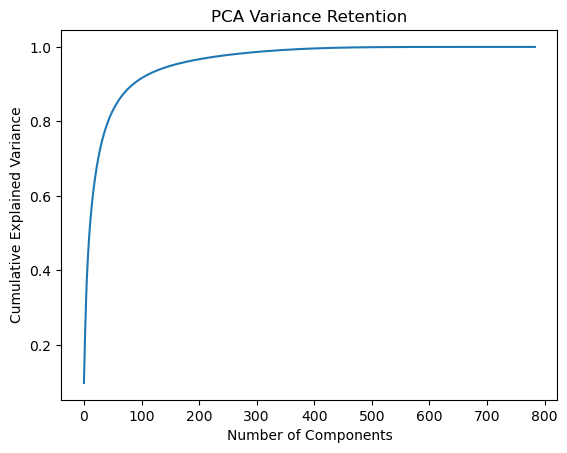

In [53]:

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Variance Retention")
plt.show()

### **scree plot** 
- The scree plot shows which components contribute most to explaining dataset variance.

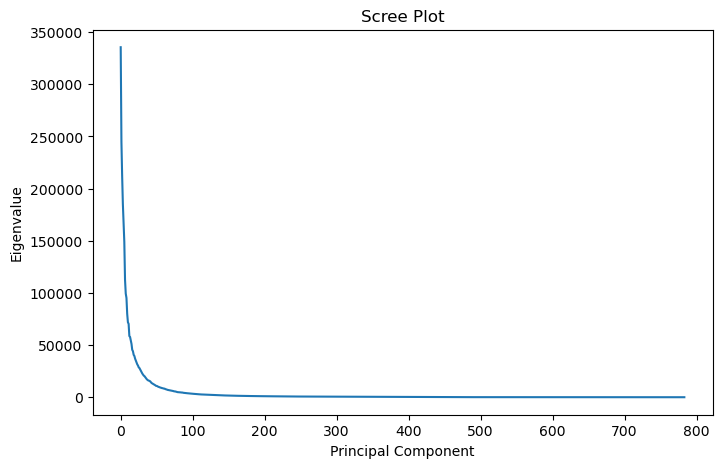

In [54]:
plt.figure(figsize=(8,5))
plt.plot(pca.explained_variance_)
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot")
plt.show()

## Selecting Components Based on 95% Variance
- PCA automatically selects the minimum number of components that preserve 95% of the dataset information.

In [55]:
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Number of components selected:", pca.n_components_)

Number of components selected: 153


In [56]:
knn = KNeighborsClassifier()

knn.fit(X_train_pca, y_train)

accuracy = knn.score(X_test_pca, y_test)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9671428571428572
